# Imports

In [12]:
%pip install pandas numpy seaborn matplotlib
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Note: you may need to restart the kernel to use updated packages.


# EDA
## Class

In [13]:
class DataWrangling(object):

    def __init__(self, dataframe):
        self.dataframe = dataframe
        # Rows and columns
        self.rows, self.columns = self.dataframe.shape

    def dataset_overview(self):
        """
        Outputs the basic overview information for the dataset
        """
        # Copy for safety
        df = self.dataframe.copy()
    
        print(51* "=")
        print(f"\nShape: {df.shape}")
        print(f"\nDtypes:\n{df.dtypes}")
        print(f"Missing values:\n{df.isnull().sum()}")
        print(51* "=")

    def target_info(self, target):
        """
        Baseline model.
        P_hat(Y=k) = n_k / n
        """
        # copy dataframe
        df = self.dataframe.copy()

        # Show class imbalance if exists
        counts = df[target].value_counts()
        # Probabilites
        probs = counts / len(df)

        print(f"\nCounts: {counts}")
        print(f"Class probabilities: {probs}")

        # INTERPRETATION
        imbalance_ratio = counts.max() / counts.min()
        print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")
        print("NOTE: Class imbalance detected." if imbalance_ratio > 1.5 else "NOTE: Classes are roughly balanced.")
        print("Consider: SMOTE, class_weight='balanced', or F1/AUC over accuracy.")

    def column_summary(self, N=10):
        """
        Provides summary of the columns such that it outputs:
            colunm_name
            column_dtype
            num_of_nulls
            num_of_non_nulls
            num_distinct_values
            min/max values
            avarage value (if number)
            non_zeros
            top_N_distinct_values
        ---------------------------------------------------
        INPUT:
            N: (int; default=10) Number of distinct values in dataframe

        OUTPUT:
            summary_df: (pd.DataFrame) Dataframe as summary of riingal dataframe
        """
        # Copy for safety purposes
        df = self.dataframe.copy()

        # Initialize summary and variables that wont work for non-numerics
        summary_rows = []

        # Iterate thru columns to get summary information
        for col in df.columns:
            # Initiate values for numeric variables
            # Incase the following IF-statement doesn't handle these variables
            min_val = max_val = med_val = avg_val = np.nan
            non_zero_num = np.nan

            column_name = col
            column_dtype = df[col].dtype
            null_num = df[col].isnull().sum()
            non_null_num = df[col].notnull().sum()

            # Parentheses avoids UnboundLocalError: 'reference before assignment'
            # 'pd.api.types.is_numeric_dtype(arr_or_dtype)'
            if pd.api.types.is_numeric_dtype(df[col]):
                min_val = df[col].min()
                max_val = df[col].max()
                med_val = df[col].median()
                avg_val = df[col].mean()
                # Summing the True values
                non_zero_num = (df[col] != 0).sum()

            # Get Top N distinct values
            distinct_vals = df[col].dropna().value_counts()

            # Number of distinct values
            num_distinct = len(distinct_vals)

            # Top N unique values
            top_N_unique = distinct_vals.head(N).index.tolist()
            
            # % of NULL values, rounding to two decimals
            null_perc = round(null_num / self.rows * 100, 2)
            
            # Append dictionary to summary rows
            # LIST of dictionaries for properties of dataframe
            summary_rows.append({
                "column_name": column_name,
                "column_dtype": column_dtype,
                "null_num": null_num,
                "non_null_num": non_null_num,
                "min_val": min_val,
                "max_val": max_val,
                "median_val": med_val,
                "avg_val": avg_val,
                "num_distinct": num_distinct,
                "non_zero_num": non_zero_num,
                "top_N_unique": top_N_unique,
                "null_pct": null_perc
            })

        # Convert Dictionary to a summary dataframe
        summary_df = pd.DataFrame(summary_rows)

        return summary_df

    def convert_datatype(self):
        """
        Converts 'object' data type to appropriate data type and classifies each s.t.
            Numerical:
                - continuous
                - discrete

            Categorical:
                - Boolean
                - non-boolean

        RULES:
            1. If object column interpreted as bool, convert to bool
            2. Numeric -> Numeric
            3. Else: category
            4. Numeric columns:
                - int -> discrete (typically)
                - float -> Continuous
            5. Categorical:
                - Exactly two unique values -> bool
                - else: categorical
        --------------------------------------------------------
        INPUT:
            None

        OUTPUT:
            df: (pd.DataFrame) Dataframe updated with variable datatypes
            var_types: (dict) Dictionary mapping column names to data types
        """
        # Use copy for safety
        df = self.dataframe.copy()

        # Store variable types
        var_types = {}

        # Iterate thru columns
        for col in df.columns:
            # Drop NA values
            non_null = df[col].dropna()

            # Skip useless columns
            if non_null.empty:
                # I.D. unknowns
                var_types[col] = "unknown_empty"
                print(f"{col}: Empty column -> unknown_empty")
                continue

            # ++++++ Object columns ++++++
            if df[col].dtype == "object":
                # Start by ensuring the strings are the same cap-size
                lowered = non_null.astype(str).str.strip().str.lower()

                # Uniques, using SET ?
                unique_vals = set(lowered.unique())
                
                # Boolean w/ no more than 2 unique values
                if len(unique_vals) == 2:
                    var_types[col] = "boolean_categorical"
                    print(f"{col}: object -> bool_categorical")
                    continue

                # Numeric conversion
                # Numeric test
                numeric_test = pd.to_numeric(non_null, errors="coerce")
                
                if numeric_test.notna().all():
                    df[col] = pd.to_numeric(df[col], errors="coerce")

                    # Discrete vs continuous
                    values = df[col].dropna()

                    # Whole-number test, using modulo operator to ensure not a float
                    is_whole = np.all(np.isclose(values % 1, 0))

                    if is_whole:
                        # Convert to integer, if you can
                        df[col] = df[col].astype("int64")
                        var_types[col] = "discrete"
                        print(f"{col}: object -> int64 | discrete")

                    else:
                        var_types[col] = "continuous"
                        print(f"{col}: object -> float | continuous")

                    continue
                
                # Else: Categorical
                df[col] = df[col].astype("category")

                # Categorical, non-boolean
                if non_null.nunique() != 2:
                    var_types[col] = "categorical"
                    print(f"{col}: object -> category | categorical")

            # +++++++++ Boolean columns +++++++++++
            elif pd.api.types.is_bool_dtype(df[col]):
                var_types[col] = "boolean"
                print(f"{col}: bool | boolean_categorical")

            # +++++++++ Numeric columns +++++++++++++
            elif pd.api.types.is_numeric_dtype(df[col]):
                values = df[col].dropna()

                if pd.api.types.is_integer_dtype(df[col]):
                    var_types[col] = "discrete"
                    print(f"{col}: Numeric | discrete")

                else:
                    # Make sure all values are @least integers
                    is_whole = np.all(np.isclose(values % 1, 0))
                    
                    if is_whole:
                        var_types[col] = "discrete"
                        print(f"{col}: numeric | discrete")

                    else:
                        var_types[col] = "continuous"
                        print(f"{col}: numeric | continuous")

            # ++++++++++ Category columns already existing +++++++
            elif isinstance(df[col].dtype, pd.CategoricalDtype):

                if non_null.nunique() == 2:
                    var_types[col] = "boolean"
                    print(f"{col}: category | boolean")

                else:
                    var_types[col] = "categorical"
                    print(f"{col}: category | categorical")

            # ++++++++ Incase nothing else +++++++++++
            else:
                var_types[col] = "unknown"
                print(f"{col}: NO CLUE ... ¯\_( ͡° ͜ʖ ͡°)_/¯")

        # Update this dataframe
        self.dataframe = df

        return df, var_types

    def baseline_accuracy(self, target):
        """
        Computes baseline model:
            P_hat(Y=mode)
        """
        df = self.dataframe.copy()

        # Get majority class for accuracy calc
        maj_class = df[target].mode()[0]
        accuracy = (df[target] == maj_class).mean()

        print(f"\nMajority class: {maj_class}")
        print(f"Accuracy: {accuracy:.3f}")

        # INTERPRETATION
        print(f"\n[Interpretation] A naive model that always predicts '{maj_class}'")
        print(f"achieves {accuracy:.1%} accuracy — any model must beat this to add value.")
        print(f"Given class imbalance, prefer F1-score or ROC-AUC over raw accuracy.")

    def target_correlation(self, target):
        """
        Correlation of numeric features with target
        """
        df = self.dataframe.copy()

        corr = df.corr(numeric_only=True)[target].sort_values(ascending=False)

        print("\n===== CORRELATION WITH TARGET =====")
        print(corr)

        # INTERPRETATION
        top_pos = corr[corr > 0].drop(target).head(3)
        top_neg = corr[corr < 0].tail(3)

        print(f"\nTop positive predictors of {target}:\n{top_pos}")
        print(f"\nTop negative predictors of {target}:\n{top_neg}")
        print("\n[Interpretation] Positive correlation: higher values → more likely to purchase.")
        print("[Interpretation] Negative correlation: higher values → less likely to purchase.")
        print("[Note] These are linear correlations only — non-linear relationships may exist.")

    def plot_target_balance(self, target):
        """
        Plots class porportions for targeet variable
        """
        df = self.dataframe.copy()

        probs = df[target].value_counts(normalize=True).sort_index()

        plt.figure()
        probs.plot(kind="bar")
        plt.title(f"Class Balance: {target}")
        plt.ylabel("Proportion")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()
    
    def plot_category_rate(self, col, target, order=None):
        """
        Plots conditional purchase rate by category: 
            P(Y = 1 | category)
        """
        df = self.dataframe.copy()

        rates = df.groupby(col, observed=False)[target].mean()

        if order is not None:
            rates = rates.reindex(order)

        plt.figure()
        rates.plot(kind="bar")
        plt.title(f"Purchase Rate by {col}")
        plt.ylabel("P(Purchase)")
        plt.xlabel(col)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def plot_box_by_target(self, col, target):
        """
        Plots distribution of a numeric feature grouped by target class
        """
        df = self.dataframe.copy()

        plt.figure()
        sns.boxplot(data=df, x=target, y=col)
        plt.title(f"{col} by {target}")
        plt.xlabel(target)
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

    def numeric_target_summary(self, cols, target):
        """
        ?
        Summary statistics of numeric variables grouped by target class.
        """
        df = self.dataframe.copy()

        summary = df.groupby(target)[cols].agg(["mean", "median", "std"])
        print("\n===== NUMERIC SUMMARY BY TARGET =====")
        print(summary)

        # INTERPRETATION
        print("\n[Interpretation] Large mean differences between classes suggest")
        print("these features have discriminative power for classification.")
        print("High std relative to mean difference suggests overlap — harder to separate.")


## Read file

In [14]:
def read_file(path):
    """
    reads file depending on file extension.
    --------------------------------------------
    INPUT:
        path: (str) Path (absolute/relative) to data file.

    OUTPUT:
        dframe: (pd.DataFrame) Dataframe of the dataset
    """
    if not isinstance(path, str):
        raise ValueError("Path provided is in wrong format!\nMust be a string")

    try:
        if path.endswith(".csv") or path.endswith(".txt"):
            dframe = pd.read_csv(path)
        elif path.endswith(".dat"):
            dframe = pd.read_csv(path, sep=r"\s+")
        else:
            raise ValueError(f"Unsupported file extension: {path}")

        return dframe

    except Exception as err:
        raise RuntimeError(f"Failed to read file '{path}': {err}")


# Run EDA

============== EDA ==============

Shape: (12330, 18)

Dtypes:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object
Missing values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay      

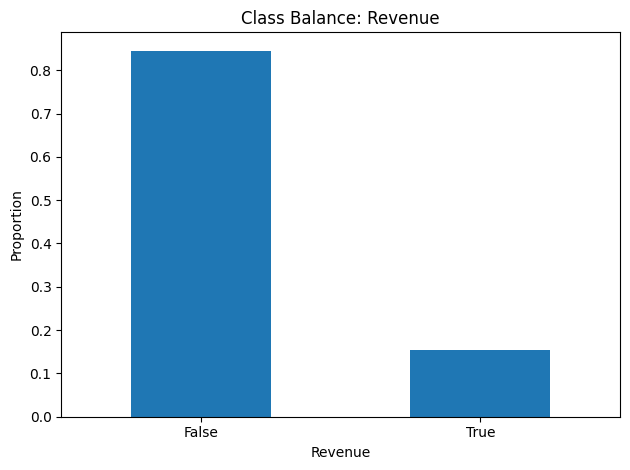

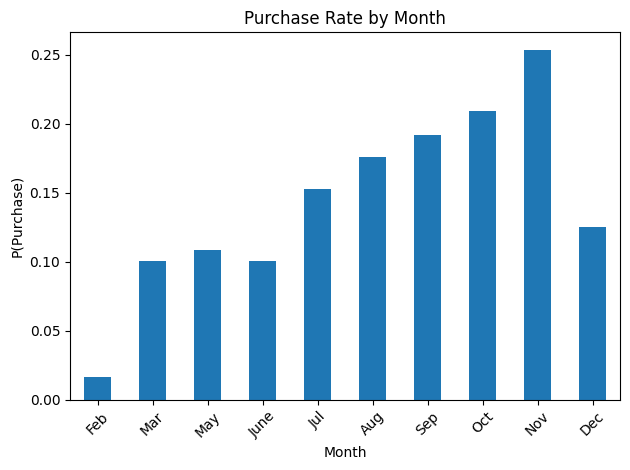

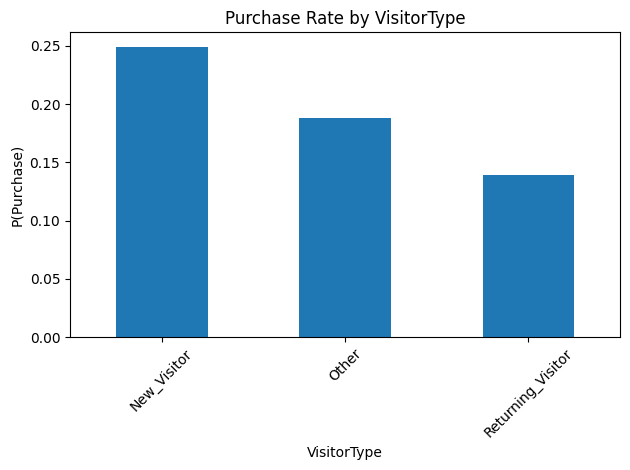

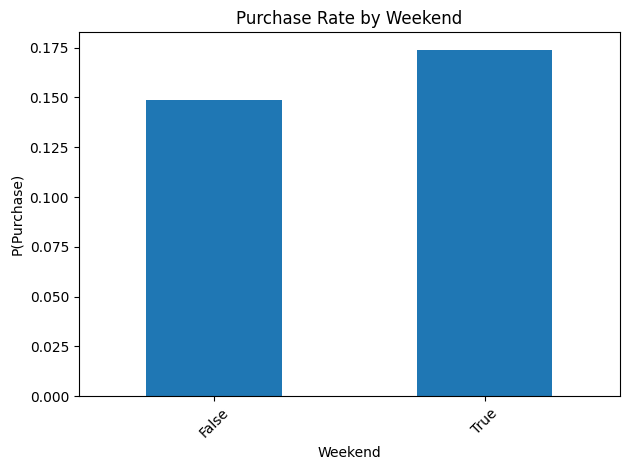

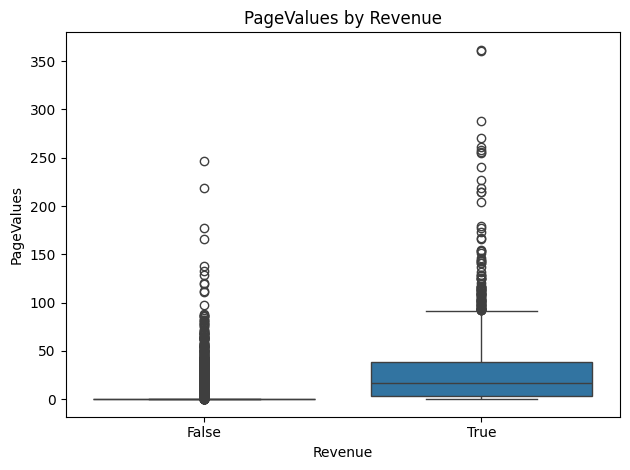


===== NUMERIC SUMMARY BY TARGET =====
        PageValues                       ExitRates                      \
              mean     median        std      mean    median       std   
Revenue                                                                  
False     1.975998   0.000000   9.072424  0.047378  0.028571  0.051231   
True     27.264518  16.758134  35.191954  0.019555  0.016000  0.016463   

        BounceRates                     ProductRelated_Duration              \
               mean    median       std                    mean      median   
Revenue                                                                       
False      0.025317  0.004255  0.051877             1069.987809   510.19000   
True       0.005117  0.000000  0.012185             1876.209615  1109.90625   

                      
                 std  
Revenue               
False    1803.797757  
True     2312.214392  

[Interpretation] Large mean differences between classes suggest
these features

In [15]:
PATH = "online_shoppers_intention.csv"
df = read_file(PATH)

wrangler = DataWrangling(df)

print("============== EDA ==============")

# Dataset overview
wrangler.dataset_overview()

# Column summary
summary = wrangler.column_summary()
print(summary)

# Convert datatypes
df, var_types = wrangler.convert_datatype()

# Target analysis
TARGET = "Revenue"
wrangler.target_info(TARGET)

# Baseline model
wrangler.baseline_accuracy(TARGET)

# Correlation with target
wrangler.target_correlation(TARGET)
wrangler.plot_target_balance(TARGET)

# Purchase probability: Revenue for the given month
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
wrangler.plot_category_rate("Month", TARGET, order=month_order)
wrangler.plot_category_rate("VisitorType", TARGET)
wrangler.plot_category_rate("Weekend", TARGET)

wrangler.plot_box_by_target("PageValues", TARGET)
wrangler.numeric_target_summary(
    ["PageValues", "ExitRates", "BounceRates", "ProductRelated_Duration"],
    TARGET
)
